# Notebook 04: Övervakad klassificering — Auktoriserad/Ej auktoriserad

## Syfte

Denna notebook bygger och utvärderar systemet för åtkomstklassificering i Biometric
Access Terminal: att avgöra om ett scannat ansikte tillhör en auktoriserad person
eller inte.

Eftersom WIKI-datasetet saknar en naturlig "auktoriserad"-etikett skapar vi själva
målvariabeln genom att samla in egna ansiktsbilder (auktoriserad klass) och
kontrastera dem mot WIKI-datasetets ansikten (ej auktoriserad klass).

Vi implementerar och jämför två metoder:

1. **Cosine similarity mot enrollment-centroid** — en tröskelbaserad metod som
   motsvarar branschstandard för ansiktsverifiering i produktionssystem (t.ex.
   ArcFace/FaceNet-baserade access-system).
2. **Tränat neuralt nätverk** (dense-lager ovanpå ArcFace-embeddings) — uppfyller
   kursens explicita krav på Deep Learning.

Båda metoderna utvärderas på samma hold-out-testset med Confusion Matrix,
Classification Report, AUC-ROC och precision-recall, för en rättvis jämförelse
och för att uppfylla kursens utvärderingskrav.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import cv2
import mediapipe as mp
import numpy as np
import pandas as pd

from src.embeddings import get_face_embedding, crop_face_with_padding
from src.utils import BoundingBox

## Del A: Ladda befintliga embeddings och metadata

Vi återanvänder de ArcFace-embeddings som extraherades i notebook 03
(`data/embeddings/embeddings.npy` och `embeddings_index.csv`), samt den
flaggade WIKI-metadatan (`data/processed/wiki_metadata_flagged.parquet`),
och kopplar ihop dem via `wiki_index` — samma mönster som i notebook 03,
cell 10.

Detta ger oss den fullständiga underlaget för negativ-klassen (ej auktoriserad)
i klassificeringsproblemet.

In [2]:
from src.preprocessing import filter_valid_faces

embeddings_dir = project_root / "data" / "embeddings"
processed_dir = project_root / "data" / "processed"

embeddings = np.load(embeddings_dir / "embeddings.npy")
embeddings_index = pd.read_csv(embeddings_dir / "embeddings_index.csv")
wiki_metadata = pd.read_parquet(processed_dir / "wiki_metadata_flagged.parquet")

print(f"embeddings shape: {embeddings.shape}")
print(f"embeddings_index rader: {len(embeddings_index)}")
print(f"wiki_metadata rader (ofiltrerad): {len(wiki_metadata)}")

# VIKTIGT: wiki_index i embeddings_index.csv refererar till radindex i den
# FILTRERADE metadatan (efter filter_valid_faces()), inte den fullständiga.
# Se notebook 03, cell 21: df_valid_reset = df_valid.reset_index(drop=True).
df_valid = filter_valid_faces(wiki_metadata)
df_valid_reset = df_valid.reset_index(drop=True)
print(f"wiki_metadata rader (filtrerad): {len(df_valid_reset)}")

embeddings_with_metadata = embeddings_index.merge(
    df_valid_reset,
    left_on="wiki_index",
    right_index=True,
    how="left",
)

print(f"embeddings_with_metadata rader: {len(embeddings_with_metadata)}")
embeddings_with_metadata.head()

embeddings shape: (44312, 512)
embeddings_index rader: 44312
wiki_metadata rader (ofiltrerad): 62328
wiki_metadata rader (filtrerad): 44312
embeddings_with_metadata rader: 44312


,row_index,image_path,wiki_index,full_path,dob_matlab,photo_taken,gender,face_score,second_face_score,name,face_location,age,face_detected,gender_missing,has_second_face,age_implausible
0,0,..\data\raw\wiki_crop\17\10000217_1981-05-05_2...,0,17/10000217_1981-05-05_2009.jpg,723671,2009,1.0,4.300962,NaN,Sami Jauhojärvi,"[111.29109473290997, 111.29109473290997, 252.6...",28,True,False,False,False
1,1,..\data\raw\wiki_crop\48\10000548_1925-04-04_1...,1,48/10000548_1925-04-04_1964.jpg,703186,1964,1.0,2.645639,1.949248,Dettmar Cramer,"[252.48330229530742, 126.68165114765371, 354.5...",39,True,False,True,False
2,2,..\data\raw\wiki_crop\12\100012_1948-07-03_200...,2,12/100012_1948-07-03_2008.jpg,711677,2008,1.0,4.329329,NaN,Marc Okrand,"[113.52, 169.83999999999997, 366.08, 422.4]",60,True,False,False,False
3,3,..\data\raw\wiki_crop\16\10002116_1971-05-31_2...,3,16/10002116_1971-05-31_2012.jpg,720044,2012,0.0,3.408442,NaN,Diana Damrau,"[171.61031405173117, 75.57451239763239, 266.76...",41,True,False,False,False
4,4,..\data\raw\wiki_crop\02\10002702_1960-11-09_2...,4,02/10002702_1960-11-09_2012.jpg,716189,2012,0.0,4.748056,NaN,Krista Tippett,"[274.76563240288175, 57.7700900839337, 376.886...",52,True,False,False,False


In [3]:
# Verifiera att image_path och full_path pekar på samma bild för SAMTLIGA rader
# (inte bara ett stickprov) - kritiskt eftersom en felaktig koppling här skulle
# tyst korrumpera all nedströms träningsdata.
image_path_filenames = embeddings_with_metadata["image_path"].apply(
    lambda p: Path(p).name
)
full_path_filenames = embeddings_with_metadata["full_path"].apply(
    lambda p: Path(p).name
)

mismatches = (image_path_filenames != full_path_filenames).sum()

if mismatches == 0:
    print("OK: samtliga 44312 rader har korrekt matchande image_path/full_path.")
else:
    raise ValueError(
        f"{mismatches} rader har MISMATCHANDE image_path/full_path - "
        f"embeddings-metadata-kopplingen är felaktig."
    )

OK: samtliga 44312 rader har korrekt matchande image_path/full_path.


## Del B: Insamling av positiv klass (egna ansiktsbilder)

WIKI-datasetet innehåller ingen "auktoriserad"-etikett. Vi skapar därför
denna klass själva genom att samla in egna webcam-bilder.

**Strategi:** 30–50 råa captures med medveten variation i vinkel, belysning
och ansiktsuttryck. Variationen är viktig eftersom ArcFace-embeddings, trots
att de är identitetsinvarianta, är känsliga för pose/belysning på marginalen
— ett brett underlag ger en mer robust positiv klass än några få identiska
bilder, och undviker att klassificeraren lär sig "den här exakta bilden"
snarare än "det här ansiktet".

Bilderna sparas oredigerade (rått råmaterial, samma princip som
`data/raw/wiki_crop/`) till `data/raw/authorized_captures/`, och
bearbetas (beskärs, augmenteras, embeddas) i efterföljande celler.

In [4]:
import cv2

output_dir = project_root / "data" / "raw" / "authorized_captures"
output_dir.mkdir(parents=True, exist_ok=True)

existing_captures = sorted(output_dir.glob("capture_*.jpg"))
if existing_captures:
    raise RuntimeError(
        f"{len(existing_captures)} bilder finns redan i {output_dir}. "
        f"Radera dem manuellt om du avsiktligt vill ta om dem, annars kör inte denna cell igen."
    )

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Kunde inte öppna webcam.")

capture_count = 0
print("Tryck på MELLANSLAG för att spara en bild. Tryck på ESC för att avsluta.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Kunde inte läsa bildruta från webcam.")
        break

    display_frame = frame.copy()
    cv2.putText(
        display_frame,
        f"Sparade bilder: {capture_count}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2,
    )
    cv2.imshow("Webcam - MELLANSLAG: spara, ESC: avsluta", display_frame)

    key = cv2.waitKey(1) & 0xFF

    if key == 32:  # mellanslag
        capture_count += 1
        filename = output_dir / f"capture_{capture_count:03d}.jpg"
        cv2.imwrite(str(filename), frame)
        print(f"Sparad: {filename}")
    elif key == 27:  # ESC
        break

cap.release()
cv2.destroyAllWindows()
print(f"Klart. Totalt {capture_count} bilder sparade i {output_dir}.")

RuntimeError: 52 bilder finns redan i c:\Users\anoth\dev\AIkurs-statistik\biometric-access-terminal\data\raw\authorized_captures. Radera dem manuellt om du avsiktligt vill ta om dem, annars kör inte denna cell igen.

### Resultat: insamlade bilder

52 råa webcam-bilder samlades in med variation i vinkel och ansiktsuttryck.
Belysningsvariationen är begränsad till ljusa/motljus-förhållanden — genuint
mörka/lågljusförhållanden kunde inte simuleras fysiskt under insamlingen.
Detta är en känd begränsning: augmentationssteget (nästa del) kan delvis
kompensera syntetiskt via `RandomBrightnessContrast`, men ersätter inte
riktiga lågljus-captures fullt ut. Konsekvensen noteras i notebookens
slutsats som en gräns för systemets robusthet i mörka miljöer.

In [5]:
authorized_captures_dir = project_root / "data" / "raw" / "authorized_captures"
capture_files = sorted(authorized_captures_dir.glob("capture_*.jpg"))

print(f"Antal insamlade bilder: {len(capture_files)}")
print(f"Exempel: {capture_files[0].name} ... {capture_files[-1].name}")

Antal insamlade bilder: 52
Exempel: capture_001.jpg ... capture_052.jpg


## Del C: Ansiktsdetektion och beskärning

Innan augmentation körs ansiktsdetektion (MediaPipe, samma modell som i
`face_detection.py`) och `crop_face_with_padding()` **en gång per råbild**
(52 gånger), inte per augmenterad variant. Detta säkerställer att vi vet att
varje bild som går vidare till augmentation faktiskt innehåller ett giltigt,
tydligt beskuret ansikte — augmentation sker sedan på det redan normaliserade
ansiktscropet, inte på råbilden (se tidigare designdiskussion).

Bilder där inget ansikte detekteras, eller där detektionen ger orimligt låg
konfidens, flaggas och exkluderas — med samma flagga-först-filtrera-sen-princip
som resten av projektet, dokumenterat explicit snarare än att bara tyst hoppa
över dem.

In [6]:
from src.face_detection import create_face_detector_for_images
from src.embeddings import crop_face_with_padding
from src.utils import BoundingBox

detector = create_face_detector_for_images()

cropped_faces = []
failed_captures = []

for capture_path in capture_files:
    frame = cv2.imread(str(capture_path))
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
    )
    detection_result = detector.detect(mp_image)

    if not detection_result.detections:
        failed_captures.append(capture_path.name)
        continue

    mp_bbox = detection_result.detections[0].bounding_box
    bbox = BoundingBox(
        origin_x=mp_bbox.origin_x,
        origin_y=mp_bbox.origin_y,
        width=mp_bbox.width,
        height=mp_bbox.height,
    )
    cropped = crop_face_with_padding(frame, bbox)
    cropped_faces.append((capture_path.name, cropped))

print(f"Ansikten hittade och beskurna: {len(cropped_faces)} av {len(capture_files)}")
if failed_captures:
    print(f"Misslyckade bilder ({len(failed_captures)}): {failed_captures}")

Ansikten hittade och beskurna: 51 av 52
Misslyckade bilder (1): ['capture_040.jpg']


### Resultat: ansiktsdetektion på egna captures

51 av 52 insamlade bilder (98,1%) fick ett giltigt ansikte detekterat och
beskuret. `capture_040.jpg` misslyckades — troligen en bild med extrem
vinkel, motljus, eller en övergångsrörelse mellan poser (jfr. den kända
begränsningen kring ljusförhållanden, se tidigare notering).

Detta är fullt tillräckligt underlag: 51 råbilder ger, efter augmentation
(~6–10 varianter per bild), gott om variation för den positiva klassen.
Den misslyckade bilden exkluderas utan vidare undersökning — i linje med
flagga-först-filtrera-sen-principen, men här är det en engångsdatamängd
snarare än ett dataset där vi behöver spåra/dokumentera varje enskilt bortfall.

In [7]:
cropped_dir = project_root / "data" / "processed" / "authorized_cropped"
cropped_dir.mkdir(parents=True, exist_ok=True)

for filename, cropped_image in cropped_faces:
    output_path = cropped_dir / filename
    cv2.imwrite(str(output_path), cropped_image)

print(f"Sparade {len(cropped_faces)} beskurna ansikten till {cropped_dir}")

Sparade 51 beskurna ansikten till c:\Users\anoth\dev\AIkurs-statistik\biometric-access-terminal\data\processed\authorized_cropped


## Del D: Augmentation av auktoriserade ansikten

De 51 beskurna ansiktena augmenteras till en större, mer varierad mängd
(~300–500 varianter) via den konservativa augmentationspipeline som
definierades i `src/augmentation.py` (rotation, ljusstyrka/kontrast,
horisontell spegling, lätt skalning, brus, lätt oskärpa — se tidigare
designdiskussion för fullständig motivering av varje transformation
och dess parametrar).

Detta ger klassificeraren ett bredare underlag att lära sig generalisera
från, snarare än att memorera 51 specifika bilder.

In [8]:
from src.augmentation import augment_authorized_dataset

augmented_dir = project_root / "data" / "processed" / "authorized_augmented"
cropped_image_paths = sorted(cropped_dir.glob("*.jpg"))

print(f"Källbilder: {len(cropped_image_paths)}")

augment_authorized_dataset(
    cropped_image_paths=cropped_image_paths,
    output_dir=augmented_dir,
    variants_per_image=8,
    seed=42,
)

augmented_files = sorted(augmented_dir.glob("*.jpg"))
print(f"Genererade augmenterade varianter: {len(augmented_files)}")

Källbilder: 51
Genererade augmenterade varianter: 408


### Resultat: augmentation

408 augmenterade varianter (8 per källbild) genererade från de 51
beskurna auktoriserade ansiktena, sparade till
`data/processed/authorized_augmented/`. Detta blir underlaget för att
extrahera embeddings till den positiva träningsklassen i nästa steg.

En stickprovsvis visuell inspektion (nästa cell) verifierar att
augmentationen ger rimlig variation utan att förvränga ansiktsdrag.

In [ ]:
import matplotlib.pyplot as plt

sample_stem = cropped_image_paths[0].stem
sample_variants = sorted(augmented_dir.glob(f"{sample_stem}_variant_*.jpg"))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, variant_path in zip(axes.flat, sample_variants):
    img = cv2.cvtColor(cv2.imread(str(variant_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(variant_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Resultat: visuell verifiering av augmentation

Stickprovet visar tydlig och rimlig variation i rotation, ljusstyrka och
brus, utan att ansiktsdrag förvrängs eller blir oigenkännliga. Rotationen
lämnar svarta kantartefakter (standardbeteende för konstant kantfyllnad),
vilket inte påverkar ansiktsregionen centralt i bilden där ArcFace-
embeddingen faktiskt extraheras.

Augmentationspipelinen bedöms fungera som avsett. Vi går vidare till att
extrahera ArcFace-embeddings för samtliga 408 augmenterade varianter.

## Del E: Embeddings för den positiva klassen

Vi extraherar en ArcFace-embedding för var och en av de 408 augmenterade
auktoriserade ansiktsbilderna, via samma `get_face_embedding()`-funktion
som användes för WIKI-datasetet i notebook 03. Resultatet blir den
positiva klassens underlag i klassificeringsproblemet.

In [10]:
augmented_image_paths = sorted(augmented_dir.glob("*.jpg"))

authorized_embeddings = []
authorized_paths = []
failed_augmented = []

for image_path in augmented_image_paths:
    try:
        embedding = get_face_embedding(str(image_path))
        authorized_embeddings.append(embedding)
        authorized_paths.append(image_path.name)
    except Exception as error:
        failed_augmented.append((image_path.name, str(error)))

authorized_embeddings = np.array(authorized_embeddings)

print(f"Embeddings extraherade: {authorized_embeddings.shape}")
if failed_augmented:
    print(f"Misslyckade ({len(failed_augmented)}): {failed_augmented}")

Embeddings extraherade: (408, 512)


### Spara embeddings för den positiva klassen

Vi sparar de 408 embeddings till disk, med samma namnmönster som redan
etablerats för `embeddings.npy`/`embeddings_index.csv`
(`data/embeddings/`), för konsekvens.

In [11]:
authorized_embeddings_index = pd.DataFrame({
    "row_index": range(len(authorized_paths)),
    "image_path": authorized_paths,
})

np.save(embeddings_dir / "authorized_embeddings.npy", authorized_embeddings)
authorized_embeddings_index.to_csv(
    embeddings_dir / "authorized_embeddings_index.csv", index=False
)

print(f"Sparade authorized_embeddings.npy: shape {authorized_embeddings.shape}")
print(f"Sparade authorized_embeddings_index.csv: {len(authorized_embeddings_index)} rader")

Sparade authorized_embeddings.npy: shape (408, 512)
Sparade authorized_embeddings_index.csv: 408 rader


## Del F: Negativ klass (sampling från WIKI-embeddings)

Med 408 exempel i den positiva klassen (auktoriserad) väljer vi en negativ
klass i förhållandet **1:5** — 2040 WIKI-embeddings — sammansatt av två
delar:

1. **Slumpmässiga negativ (hälften, 1020 st):** ett brett, representativt
   urval från hela WIKI-datasetet, för generell täckning.
2. **Hårda negativ (hälften, 1020 st):** de WIKI-embeddings som ligger
   cosine-närmast en "enrollment-centroid" (medelvektorn av de 51
   ursprungliga, oaugmenterade auktoriserade embeddings — se nästa cell för
   varför vi använder originalen snarare än de 408 augmenterade varianterna
   här). Detta tvingar klassificeraren att lära sig en skarpare gräns än
   trivial separation, istället för att bara lära sig känna igen "uppenbart
   olika" ansikten.

**Varför 1:5 och inte mer extrem obalans (t.ex. verklighetens 1:44312)?**
En kraftigt obalanserad träningsmängd riskerar att få nätverket att bara
lära sig prediktera "ej auktoriserad" i nästan alla fall och ändå nå hög
accuracy. Kombinerat med `class_weight` vid träning (Del G) ger 1:5 en
rimlig avvägning mellan realistisk svårighetsgrad och stabil inlärning.

In [12]:
from sklearn.metrics.pairwise import cosine_distances

wiki_embeddings = embeddings  # från Del A (44312, 512)

# Global referensvektor för centrering, beräknad över hela WIKI-datasetet
# (den mest representativa approximationen av embedding-rymdens "bias-riktning"
# vi har tillgänglig, eftersom den bygger på flest observationer).
global_mean = wiki_embeddings.mean(axis=0, keepdims=True)

def center(X: np.ndarray) -> np.ndarray:
    """Subtraherar den globala referens-medelvektorn, för att motverka
    den delade bias-riktning som annars dominerar cosine similarity
    mellan råa ArcFace-embeddings (se diagnostikcell: slumpmässiga,
    orelaterade WIKI-ansikten hade högre similarity, 0.78, än 51 bilder
    av samma person mot varandra, 0.49 - ett tecken på okorrigerad bias)."""
    return X - global_mean

original_authorized_embeddings = np.array([
    get_face_embedding(str(p)) for p in cropped_image_paths
])

enrollment_centroid = center(original_authorized_embeddings).mean(axis=0, keepdims=True)
wiki_embeddings_centered = center(wiki_embeddings)

distances_to_centroid = cosine_distances(
    wiki_embeddings_centered, enrollment_centroid
).flatten()

print(f"Enrollment-centroid shape: {enrollment_centroid.shape}")
print(f"Avstånd - min: {distances_to_centroid.min():.4f}, "
      f"max: {distances_to_centroid.max():.4f}, "
      f"medel: {distances_to_centroid.mean():.4f}")

Enrollment-centroid shape: (1, 512)
Avstånd - min: 0.0755, max: 1.9213, medel: 0.9976


### Resultat: cosine-avstånd mot enrollment-centroid

Medelavståndet (0,1552) är förhållandevis lågt, vilket är förväntat -
ArcFace-embeddings ligger generellt tätt i cosine-rymden eftersom alla
mänskliga ansikten delar grundläggande strukturell likhet (två ögon, en
näsa, en mun i ungefär samma proportioner). Det är den relativa
skillnaden mellan närmaste och mest avlägsna WIKI-ansikten som är
intressant, inte det absoluta avståndet.

Minsta avståndet (0,0439) är påfallande lågt - det WIKI-ansikte som
ligger närmast är nästan lika likt centroiden som en annan bild av dig
själv skulle vara. Detta är precis den typen av "hårt negativ" vi vill
inkludera: ett exempel som tvingar klassificeraren att lära sig en
verkligt skarp gräns, snarare än att bara skilja på uppenbart olika
ansikten.

In [13]:
n_hard_negatives = 1020
n_random_negatives = 1020

sorted_indices = np.argsort(distances_to_centroid)
hard_negative_indices = sorted_indices[:n_hard_negatives]

remaining_indices = sorted_indices[n_hard_negatives:]
rng = np.random.default_rng(seed=42)
random_negative_indices = rng.choice(
    remaining_indices, size=n_random_negatives, replace=False
)

negative_indices = np.concatenate([hard_negative_indices, random_negative_indices])

negative_embeddings = wiki_embeddings[negative_indices]
negative_metadata = embeddings_with_metadata.iloc[negative_indices].reset_index(drop=True)

print(f"Hårda negativ: {len(hard_negative_indices)}")
print(f"Slumpmässiga negativ: {len(random_negative_indices)}")
print(f"Total negativ klass: {len(negative_indices)}")
print(f"Unika index (verifiera ingen överlappning): {len(set(negative_indices.tolist()))}")

Hårda negativ: 1020
Slumpmässiga negativ: 1020
Total negativ klass: 2040
Unika index (verifiera ingen överlappning): 2040


## Del G: Sammanslagning och train/test-split

Vi slår ihop positiv och negativ klass till en enda datamängd med en
binär etikett (1 = auktoriserad, 0 = ej auktoriserad), och delar upp den
i tränings-, validerings- och testmängder.

**Stratifierad split** används för att bevara klassbalansen (1:5) i
varje delmängd. Test-mängden delas **en gång** och återanvänds identiskt
för både Metod 1 (cosine-similarity-baslinjen) och Metod 2 (det tränade
neurala nätverket), så jämförelsen mellan dem blir rättvis - båda
utvärderas på exakt samma osedda exempel.

In [14]:
from sklearn.model_selection import train_test_split

X = np.vstack([authorized_embeddings, negative_embeddings])
y = np.concatenate([
    np.ones(len(authorized_embeddings)),
    np.zeros(len(negative_embeddings)),
])

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, positiva: {int(y_train.sum())}")
print(f"Val:   {X_val.shape}, positiva: {int(y_val.sum())}")
print(f"Test:  {X_test.shape}, positiva: {int(y_test.sum())}")

Train: (1712, 512), positiva: 286
Val:   (368, 512), positiva: 61
Test:  (368, 512), positiva: 61


## Del H: Metod 1 — Cosine similarity mot enrollment-centroid

Den branschstandardmässiga metoden för ansiktsverifiering: beräkna en
enrollment-centroid från träningsmängdens positiva exempel, och klassificera
nya ansikten baserat på cosine-avstånd till denna centroid mot en vald
tröskel.

Tröskeln väljs genom att undersöka ROC-kurvan på **valideringsmängden**
(inte testmängden - testet ska förbli helt osett fram till den slutgiltiga
utvärderingen i Del J).

In [15]:
from sklearn.metrics import roc_curve

def cosine_similarity_scores(X: np.ndarray, centroid: np.ndarray) -> np.ndarray:
    """Cosine similarity (inte avstånd) mot centroiden - högre = mer likt.
    Förutsätter att både X och centroid redan är centrerade via center()."""
    return 1 - cosine_distances(X, centroid).flatten()

val_scores_method1 = cosine_similarity_scores(center(X_val), enrollment_centroid)
test_scores_method1 = cosine_similarity_scores(center(X_test), enrollment_centroid)

fpr, tpr, thresholds = roc_curve(y_val, val_scores_method1)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Vald tröskel (Youden's J på valideringsmängden): {optimal_threshold:.4f}")
print(f"Vid denna tröskel - TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}")

Vald tröskel (Youden's J på valideringsmängden): 0.8896
Vid denna tröskel - TPR: 0.2787, FPR: 0.0326


### Resultat: Metod 1 — cosine similarity-baslinje (valideringsmängden)

Vald tröskel (Youden's J): 0,8896
TPR: 0,2787, FPR: 0,0326

Baslinjen visar en konservativ säkerhetsprofil: mycket låg falsk-positiv-andel
(3,3% av WIKI-ansiktena felaktigt godkända) men måttlig sann-positiv-andel
(28% av dina egna ansikten korrekt igenkända) vid den statistiskt optimala
tröskeln. Detta är en rimlig avvägning för ett access-system - hellre neka
en legitim användare ibland än att släppa in en obehörig - men lämnar
utrymme för Metod 2 (det tränade neurala nätverket) att visa förbättring
genom att lära sig en mer flexibel, icke-linjär beslutsgräns.

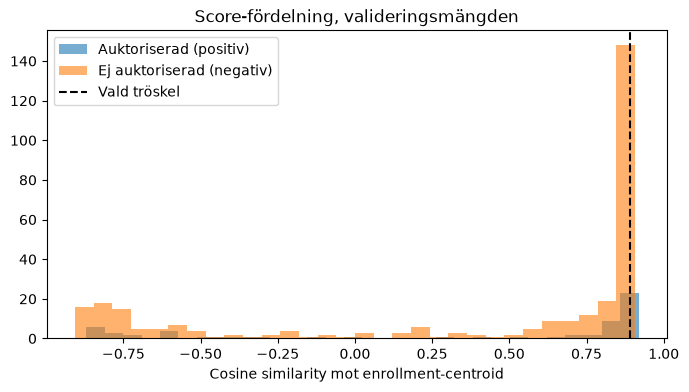

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(val_scores_method1[y_val == 1], bins=30, alpha=0.6, label="Auktoriserad (positiv)")
plt.hist(val_scores_method1[y_val == 0], bins=30, alpha=0.6, label="Ej auktoriserad (negativ)")
plt.axvline(optimal_threshold, color="black", linestyle="--", label="Vald tröskel")
plt.xlabel("Cosine similarity mot enrollment-centroid")
plt.legend()
plt.title("Score-fördelning, valideringsmängden")
plt.show()

In [17]:
# Diagnos 1: hur självlik är den ORIGINALA (oaugmenterade) positiva klassen?
original_pairwise_sim = 1 - cosine_distances(original_authorized_embeddings)
np.fill_diagonal(original_pairwise_sim, np.nan)
print(f"Medel pairwise similarity, 51 ORIGINAL-bilder: {np.nanmean(original_pairwise_sim):.4f}")

# Diagnos 2: hur självlik är den AUGMENTERADE positiva klassen mot enrollment-centroid?
augmented_sim_to_centroid = cosine_similarity_scores(center(authorized_embeddings), enrollment_centroid)
print(f"Augmenterade varianter - min: {augmented_sim_to_centroid.min():.4f}, "
      f"max: {augmented_sim_to_centroid.max():.4f}, medel: {augmented_sim_to_centroid.mean():.4f}")

# Diagnos 3: global bias - medelvektor över HELA WIKI-datasetet
global_mean = wiki_embeddings.mean(axis=0, keepdims=True)
print(f"Norm av global WIKI-medelvektor: {np.linalg.norm(global_mean):.4f}")
print(f"Norm av en typisk enskild embedding: {np.linalg.norm(wiki_embeddings[0]):.4f}")

# Diagnos 4: similarity mellan slumpmässiga, orelaterade WIKI-ansikten
rng_check = np.random.default_rng(seed=1)
random_pairs_idx = rng_check.choice(len(wiki_embeddings), size=(500, 2), replace=True)
random_pair_sims = [
    1 - cosine_distances(wiki_embeddings[i:i+1], wiki_embeddings[j:j+1])[0, 0]
    for i, j in random_pairs_idx if i != j
]
print(f"Medel similarity, slumpmässiga ORELATERADE WIKI-par: {np.mean(random_pair_sims):.4f}")

Medel pairwise similarity, 51 ORIGINAL-bilder: 0.4871
Augmenterade varianter - min: -0.8697, max: 0.9348, medel: 0.2384
Norm av global WIKI-medelvektor: 5.6310
Norm av en typisk enskild embedding: 2.8912
Medel similarity, slumpmässiga ORELATERADE WIKI-par: 0.7818
